<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practicas/sp_4_maria_sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>

Para este ejercicio de detección de valores atípicos utilizando diferentes técnicas, usaré el dataset  MODARIA II específicamente las concetraciones del radinucleido el cesio (Cs) para el ejercicio 1 y 2 como radionúcleido de interés, ya que es importante por su relevancia radiológica y su origen antropogénico, lo que lo convierte en un marcador clave de contaminación por fisión nuclear con una vida media larga.
Para los ejercicios 2 y 4 se analizarán las concentraciones de uranio debido a su importancia radiológica como radionúcleido primordial.

**Ejercicio 1: Intervalo IQR**

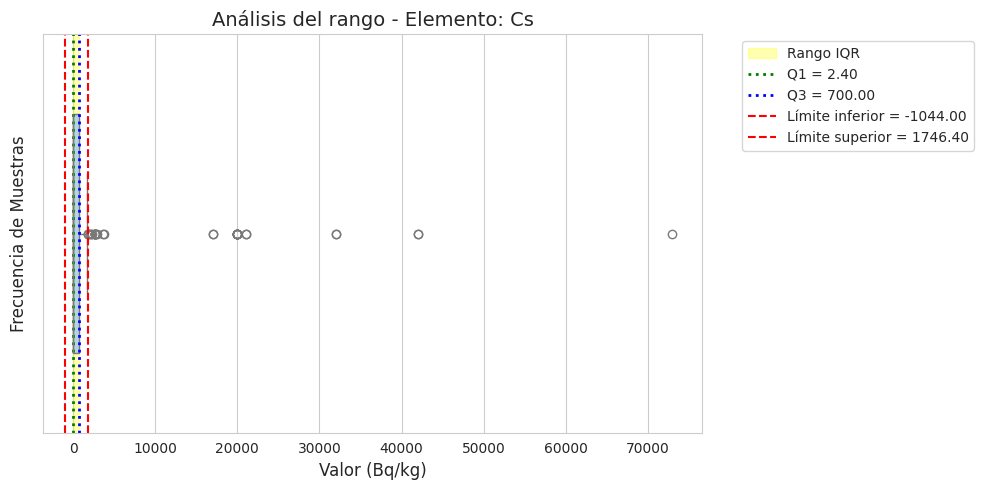

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga y Limpieza (Mismo proceso)
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)
df['C_soil_limpia'] = pd.to_numeric(df['C_soil'].astype(str).str.replace('<', '', regex=False), errors='coerce')

# Filtro para Cs
data = df[df['Element'] == 'Cs']['C_soil_limpia'].dropna().values

# 2. Cálculos Estadísticos
Q1, Q3 = np.percentile(data, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# 3. Gráfica con el estilo solicitado
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Dibujar el Boxplot
ax = sns.boxplot(x=data, color="lightblue", width=0.6)

# Sombreado del Rango IQR (Fondo amarillo)
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')

# Líneas de Cuartiles (Punteadas)
plt.axvline(Q1, color='green', linestyle=':', linewidth=2, label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', linewidth=2, label=f'Q3 = {Q3:.2f}')

# Líneas de Límites (Rojas discontinuas)
plt.axvline(lim_inf, color='red', linestyle='--', linewidth=1.5, label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', linewidth=1.5, label=f'Límite superior = {lim_sup:.2f}')

# Personalización final
plt.title("Análisis del rango - Elemento: Cs", fontsize=14)
plt.xlabel("Valor (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia de Muestras", fontsize=12) # Eje Y como pides
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


Al aplicar el método del rango intercuartílico (IQR), se detecta una distribución muy sesgada hacia la derecha. El rango IQR (área en amarillo) está muy comprimido cerca del origen, con Q1 = 2.40 Bq/kg y Q3 = 700 Bq/kg. Este intervalo concentra el 50 % de las muestras y refleja los niveles de fondo típicos de cesio-137 en suelos tropicales.
Por el contrario, los valores atípicos se extienden de forma marcada hasta aproximadamente 70000 Bq/kg. Los puntos que superan el límite superior del rango ($  1746.40  $ Bq/kg) no corresponden a errores de medición, sino a hotspots reales donde procesos edáficos y ambientales específicos concentran el material radiactivo. Aunque la  mayoría de las muestras del dataset MODARIA II Tropical presenta concentraciones muy bajas que son consistentes con la fuerte lixiviación típica de los trópicos, el riesgo radiológico significativo se concentra precisamente en estos valores atípicos debido a sus elevadas concentraciones.
Estos valores atípicos reflejan dinámicas complejas de retención y precipitación que cambian según el tipo de suelo, la historia de deposición y las condiciones locales de cada sitio de muestreo.


**Ejercicio 2: Graficos de Dispersión**

Para analizar los valores atípicos, utilice las concentraciones de cesio en el suelo y en la planta simultáneamente. Si una planta presenta altos niveles de cesio y el suelo tiene bajos, esto indica un valor atípico que revela detalles sobre la absorción, un aspecto que quiero detectar mediante el IQR y el Z-score.

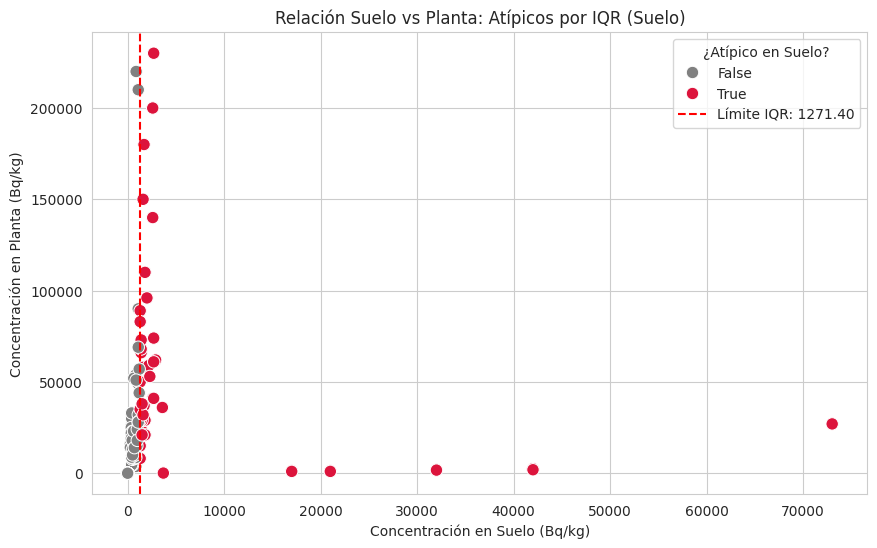

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga y limpieza de datos MODARIA
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar(col):
    return pd.to_numeric(df[col].astype(str).str.replace('<', '', regex=False), errors='coerce')

df['C_soil_limpia'] = limpiar('C_soil')
df['C_plant_limpia'] = limpiar('C_plant')
df_cs = df[df['Element'] == 'Cs'][['C_soil_limpia', 'C_plant_limpia']].dropna()

# --- LÓGICA IQR ---
x = df_cs['C_soil_limpia'].values
Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1
limite_iqr = Q3 + 1.5 * IQR
df_cs['es_atipico'] = df_cs['C_soil_limpia'] > limite_iqr

# Gráfica
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cs, x='C_soil_limpia', y='C_plant_limpia',
                hue='es_atipico', palette={False: "gray", True: "crimson"}, s=80)
plt.axvline(limite_iqr, color='red', linestyle='--', label=f'Límite IQR: {limite_iqr:.2f}')
plt.title("Relación Suelo vs Planta: Atípicos por IQR (Suelo)")
plt.xlabel("Concentración en Suelo (Bq/kg)")
plt.ylabel("Concentración en Planta (Bq/kg)")
plt.legend(title="Atípico en Suelo")
plt.show()

Usando el método de rango intercuartílico (IQR), se consideran atípicas (puntos rojos) todas las observaciones que superan el límite de 1746.40 Bq/kg, alcanzando picos de hasta 70,000 Bq/kg.
La presencia de estos outliers, especialmente agrupados en ciertos índices, indica eventos de deposición o condiciones específicas en ecosistemas tropicales. La gráfica revela que, aunque el 75% de los datos se ubica en rangos de baja actividad, el riesgo radiológico y la variabilidad del Cesio se centran en estos puntos extremos, lo que los convierte en casos que deben evaluarse de manera independiente en los análisis ambientales.


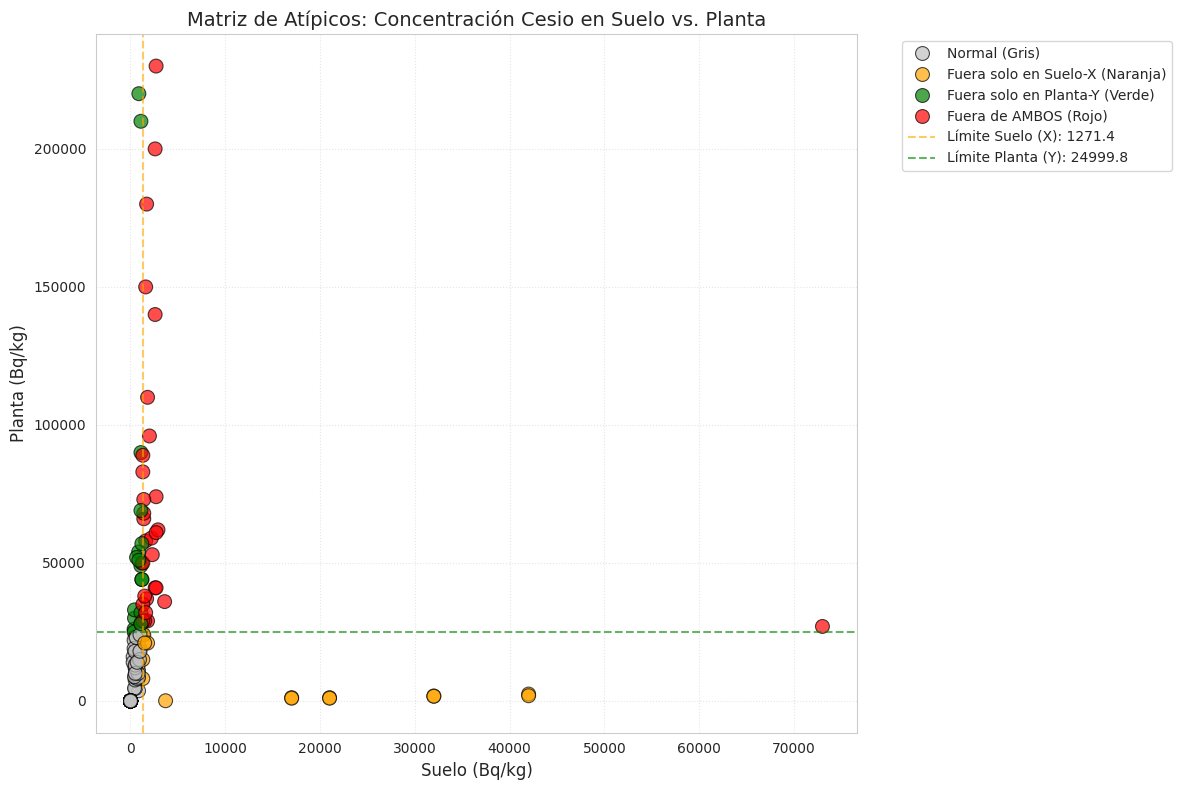

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga y limpieza de datos
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar(col):
    return pd.to_numeric(df[col].astype(str).str.replace('<', '', regex=False), errors='coerce')

df['C_soil_limpia'] = limpiar('C_soil')
df['C_plant_limpia'] = limpiar('C_plant')
df_cs = df[df['Element'] == 'Cs'][['C_soil_limpia', 'C_plant_limpia']].dropna()

# 2. Cálculo de límites IQR para ambas variables
def get_lim(data):
    q1, q3 = np.percentile(data, [25, 75])
    return q3 + 1.5 * (q3 - q1)

lim_x = get_lim(df_cs['C_soil_limpia'])
lim_y = get_lim(df_cs['C_plant_limpia'])

# 3. Lógica de colores (Categorización)
def categorizar(row):
    en_x = row['C_soil_limpia'] > lim_x
    en_y = row['C_plant_limpia'] > lim_y
    if en_x and en_y: return 'Fuera de AMBOS (Rojo)'
    if en_x: return 'Fuera solo en Suelo-X (Naranja)'
    if en_y: return 'Fuera solo en Planta-Y (Verde)'
    return 'Normal (Gris)'

df_cs['Categoria'] = df_cs.apply(categorizar, axis=1)

# 4. Gráfica Final
plt.figure(figsize=(12, 8))
colores = {'Fuera de AMBOS (Rojo)': 'red', 'Fuera solo en Suelo-X (Naranja)': 'orange',
           'Fuera solo en Planta-Y (Verde)': 'green', 'Normal (Gris)': 'silver'}

sns.scatterplot(data=df_cs, x='C_soil_limpia', y='C_plant_limpia',
                hue='Categoria', palette=colores, s=100, alpha=0.7, edgecolor='black')

# Dibujar las líneas de los límites
plt.axvline(lim_x, color='orange', linestyle='--', alpha=0.6, label=f'Límite Suelo (X): {lim_x:.1f}')
plt.axhline(lim_y, color='green', linestyle='--', alpha=0.6, label=f'Límite Planta (Y): {lim_y:.1f}')

plt.title("Matriz de Atípicos: Concentración Cesio en Suelo vs. Planta", fontsize=14)
plt.xlabel("Suelo (Bq/kg)", fontsize=12)
plt.ylabel("Planta (Bq/kg)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Al aplicar el rango intercuartílico (IQR) de forma independiente a la concentración de cesio en el suelo y en las plantas, pero visualizándolos juntos en esta gráfica, se detectan con muy alta sensibilidad los “hotspots” o puntos de acumulación radiactiva.

La gran mayoría de las muestras se agrupan cerca del origen (concentraciones bajas tanto en suelo como en planta), lo que indica que, en general, los niveles de cesio son bajos en este ecosistema. Sin embargo, aparecen varios puntos que se desvían claramente de esa tendencia.

Los suelos con concentraciones moderadas pero atípicas (puntos naranjas) no provocan una transferencia importante de cesio hacia las plantas.
Aunque el suelo está fuera del IQR, la planta se mantiene dentro deL IQR. Esto muestra un comportamiento “errático” o poco predecible: el cesio del suelo no pasa fácilmente a la planta en estos casos.
Por otro lado, sí existen casos donde la planta acumula mucho cesio (puntos verdes y rojos altos en el eje Y) aunque el suelo esté dentro del IQR. Esto sugiere que hay otros factores (posiblemente biológicos o ambientales) que favorecen la absorción en la planta de forma independiente del suelo.

En resumen, el método del IQR actúa como un filtro preciso y ajustado me detecta contaminaciones que, aunque no sean catastróficas, son estadísticamente relevantes para el ecosistema tropical. Así se pueden identificar zonas de riesgo temprano sin exagerar ni pasar por alto anomalías importantes.

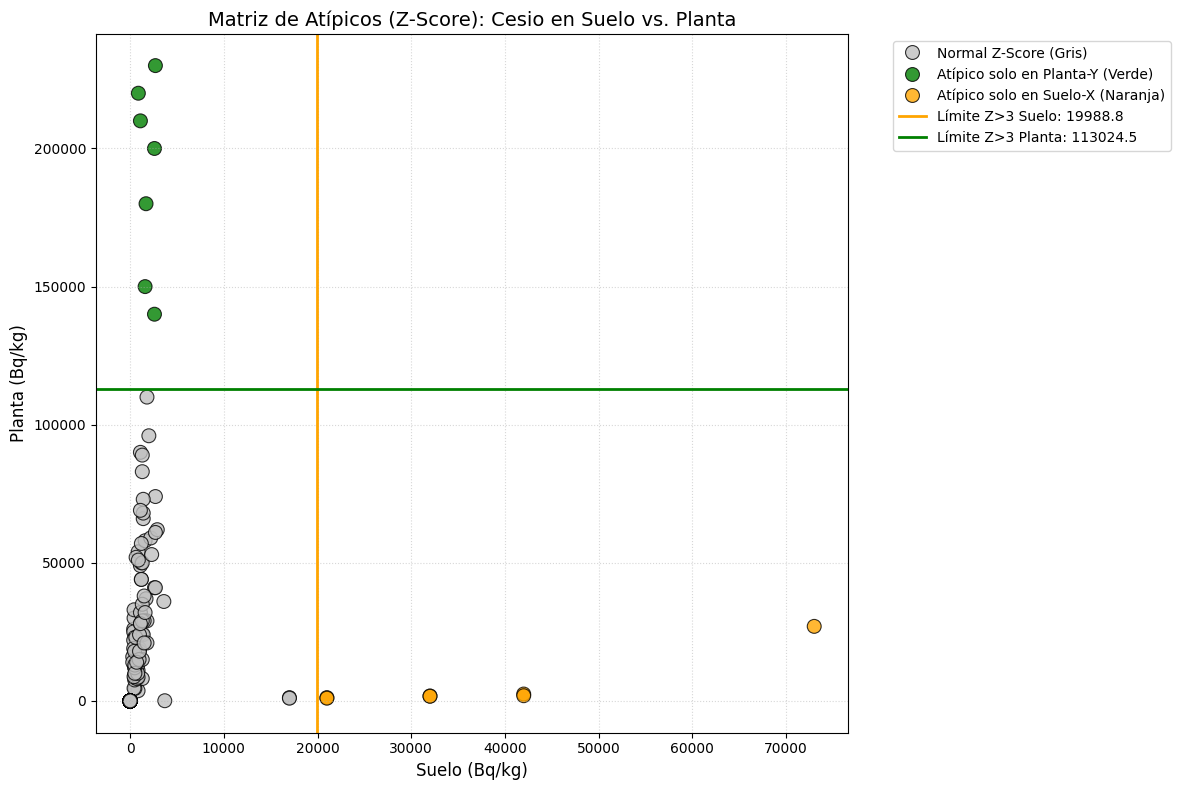

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Carga y limpieza de datos
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar(col):
    return pd.to_numeric(df[col].astype(str).str.replace('<', '', regex=False), errors='coerce')

df['C_soil_limpia'] = limpiar('C_soil')
df['C_plant_limpia'] = limpiar('C_plant')
df_cs = df[df['Element'] == 'Cs'][['C_soil_limpia', 'C_plant_limpia']].dropna()

# 2. Cálculo de Z-Scores y Límites (Media + 3*Std)
def get_z_info(data):
    media = np.mean(data)
    desv = np.std(data)
    return media, desv, media + 3 * desv

m_x, s_x, lim_z_x = get_z_info(df_cs['C_soil_limpia'])
m_y, s_y, lim_z_y = get_z_info(df_cs['C_plant_limpia'])

# 3. Lógica de colores (Categorización por Z-Score > 3)
def categorizar_z(row):
    # Calculamos si el valor individual supera las 3 desviaciones estándar
    en_x = row['C_soil_limpia'] > lim_z_x
    en_y = row['C_plant_limpia'] > lim_z_y
    if en_x and en_y: return 'Atípico Extremo AMBOS (Rojo)'
    if en_x: return 'Atípico solo en Suelo-X (Naranja)'
    if en_y: return 'Atípico solo en Planta-Y (Verde)'
    return 'Normal Z-Score (Gris)'

df_cs['Categoria_Z'] = df_cs.apply(categorizar_z, axis=1)

# 4. Gráfica Final
plt.figure(figsize=(12, 8))
colores_z = {'Atípico Extremo AMBOS (Rojo)': 'red', 'Atípico solo en Suelo-X (Naranja)': 'orange',
             'Atípico solo en Planta-Y (Verde)': 'green', 'Normal Z-Score (Gris)': 'silver'}

sns.scatterplot(data=df_cs, x='C_soil_limpia', y='C_plant_limpia',
                hue='Categoria_Z', palette=colores_z, s=100, alpha=0.8, edgecolor='black')

# Dibujar las líneas de los límites Z=3
plt.axvline(lim_z_x, color='orange', linestyle='-', linewidth=2, label=f'Límite Z>3 Suelo: {lim_z_x:.1f}')
plt.axhline(lim_z_y, color='green', linestyle='-', linewidth=2, label=f'Límite Z>3 Planta: {lim_z_y:.1f}')

plt.title("Matriz de Atípicos (Z-Score): Cesio en Suelo vs. Planta", fontsize=14)
plt.xlabel("Suelo (Bq/kg)", fontsize=12)
plt.ylabel("Planta (Bq/kg)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Al aplicar el Z-Score de manera independiente para cada variable (suelo y planta) y mostrarlas juntas en esta matriz, se puede ver que la mayoría de las muestras tienen niveles bajos de cesio en ambos, suelo y plantas. Sin embargo, hay algunos puntos que se apartan claramente de esta tendencia general.

Los suelos con concentraciones moderadas pero atípicas (puntos amarillos, por encima de 19 988,8 Bq/kg) no generan una transferencia significativa de cesio hacia las plantas. Aunque el suelo presenta niveles elevados respecto al resto de las muestras, la concentración en la planta se mantiene debajo de la linea amarilla. Esto indica que la relación entre la contaminación del suelo y la absorción por parte de la planta no siempre es directa ni proporcional.
Por otro lado, se identifican casos donde las plantas acumulan concentraciones muy altas de cesio (puntos verdes, por encima de 113 024,5 Bq/kg) aunque el suelo se encuentre en niveles normales o bajos.


**Diferencia entre métodos:**
El rango intercuartílico (IQR) es más sensible visualmente, identificando muchos más puntos fuera de los límites y resaltando mejor los “hotspots” moderados. En cambio, el Z-Score es más conservador, solo detectando los casos más extremos y dejando muchos puntos en la zona gris (normal). En resumen, para este conjunto de datos del ecosistema tropical, el método IQR permite una detección más completa de anomalías en la acumulación de cesio, mientras que el Z-Score resulta más restrictivo debido al fuerte sesgo en la distribución.

**Ejercicio 3: Histograma y Función de Densidad (Uranio)**

Para el análisis de los ejercicios 3 y 4, elegí trabajar con el radionúcleido uranio (U) en lugar de cesio-137. Esta decisión me permite variar el enfoque respecto al cesio y analizar el comportamiento de otro contaminante radiactivo relevante para el medio ambiente. El uranio es un elemento que se encuentra de forma natural en la corteza terrestre, aunque también puede originarse en actividades humanas como la minería, el procesamiento de minerales o residuos de la industria nuclear. Estudiar su distribución en el suelo es importante, ya que su concentración puede indicar posibles hotspots de contaminación y facilitar una mejor comprensión de los patrones de acumulación de radionucleidos en ecosistemas tropicales.


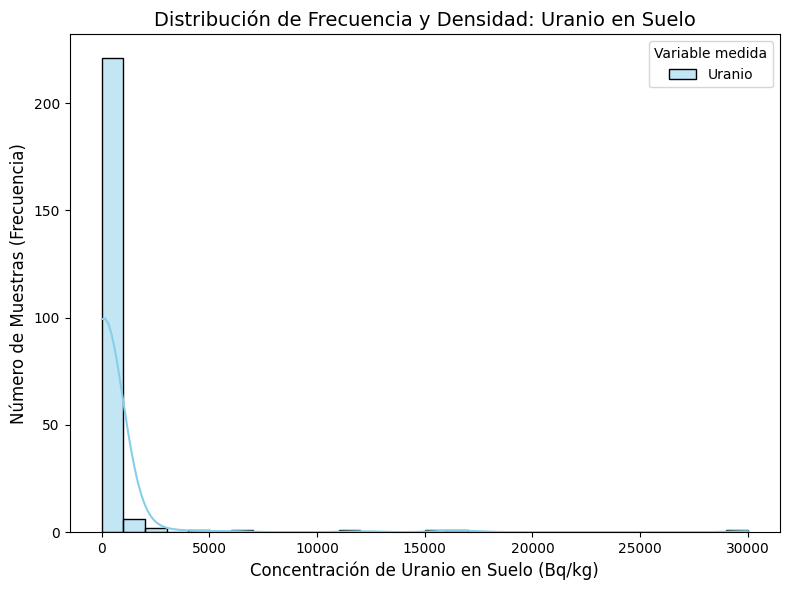

In [8]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga y limpieza de datos
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar(col):
    return pd.to_numeric(df[col].astype(str).str.replace('<', '', regex=False), errors='coerce')

df['C_soil_limpia'] = limpiar('C_soil')
df['C_plant_limpia'] = limpiar('C_plant')

# 2. Filtramos solo Uranio (cambio 'Cs' por 'U')
df_u = df[df['Element'] == 'U'][['C_soil_limpia', 'C_plant_limpia']].dropna()

# 3. Preparamos los datos para graficar
x = df_u["C_soil_limpia"].values

# 4. Gráfica mejorada
plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=30, kde=True, color="skyblue", label="Uranio")

plt.xlabel("Concentración de Uranio en Suelo (Bq/kg)", fontsize=12)
plt.ylabel("Número de Muestras (Frecuencia)", fontsize=12)
plt.title("Distribución de Frecuencia y Densidad: Uranio en Suelo", fontsize=14)
plt.legend(title="Variable medida")

plt.tight_layout()
plt.show()

La distribución de frecuencia y densidad de la concentración de Uranio en suelo muestra un comportamiento fuertemente sesgado a la derecha (asimetría positiva extrema), muy similar al observado con el Cesio-137.
La mayoría de las muestras muestran valores muy bajos, cerca de 0 Bq/kg, donde se registra la mayor frecuencia (más de 220 muestras en el primer bin) y el pico más alto en la curva de densidad. A partir de 5,000 Bq/kg, la frecuencia cae drásticamente, formando una cola larga y delgada que llega hasta aproximadamente 30,000 Bq/kg. Esta distribución sugiere que los niveles de uranio en el suelo son, en general, bajos en la mayoría de las áreas analizadas, aunque existen algunos valores extremos significativamente alejados de la tendencia principal. Estos puntos en la cola derecha pueden considerarse atípicos o hotspots de concentración de uranio, que requieren atención especial, ya que podrían relacionarse con factores geológicos naturales o influencias antropogénicas en el ecosistema tropical estudiado.

**Ejercicio 4: Z-sccore (Uranio)**

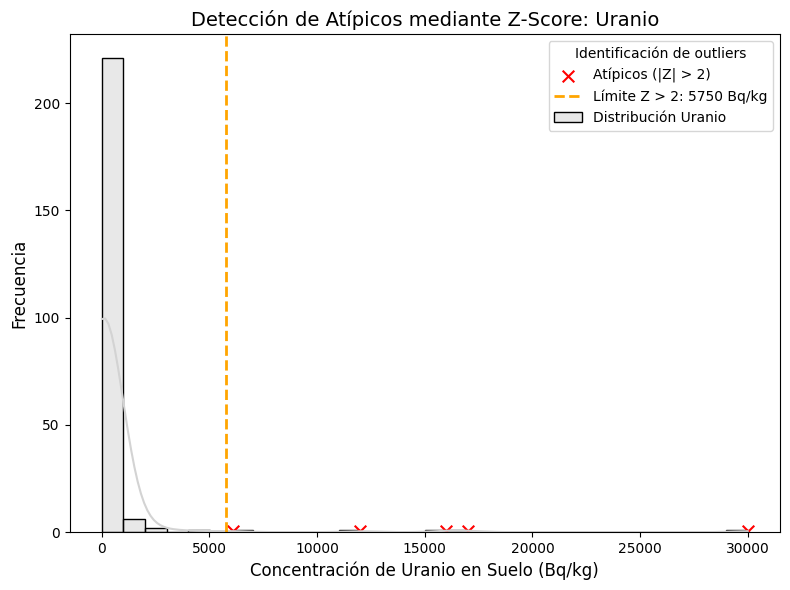

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# 1. Carga y limpieza de datos
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar(col):
    return pd.to_numeric(df[col].astype(str).str.replace('<', '', regex=False), errors='coerce')

df['C_soil_limpia'] = limpiar('C_soil')
df['C_plant_limpia'] = limpiar('C_plant')

# 2. Filtramos solo Uranio
df_u = df[df['Element'] == 'U'][['C_soil_limpia']].dropna()

# 3. Datos para graficar
x = df_u["C_soil_limpia"].values

# === CÁLCULO DEL Z-SCORE Y LÍMITE ===
z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

# Calcular el valor exacto donde Z = 2 para dibujar la línea
media = np.mean(x)
std = np.std(x)
limite_z2 = media + 2 * std

# 4. Gráfica con la línea del Z-Score
plt.figure(figsize=(8, 6))

sns.histplot(x=x, bins=30, kde=True, color="lightgray", label="Distribución Uranio")

plt.scatter(x[data_b], np.zeros_like(x[data_b]) + 0.5,
            color="red", s=70, marker="x", label="Atípicos (|Z| > 2)")

#LÍNEA DEL Z-SCORe
plt.axvline(limite_z2, color='orange', linestyle='--', linewidth=2,
            label=f'Límite Z > 2: {limite_z2:.0f} Bq/kg')

plt.xlabel("Concentración de Uranio en Suelo (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Detección de Atípicos mediante Z-Score: Uranio", fontsize=14)
plt.legend(title="Identificación de outliers")

plt.tight_layout()
plt.show()

La detección de atípicos mediante el método Z-Score para las concentraciones de Uranio en suelo muestra una distribución fuertemente sesgada a la derecha, con la gran mayoría de las muestras concentradas en valores muy bajos cercanos a 0 Bq/kg (frecuencia superior a 220 en la primera barra de la gráfica). Los puntos marcados con cruces rojas (X) representan los valores atípicos identificados cuando |Z-score| > 2 y se ubican claramente en la cola extrema de la distribución, aproximadamente en 8 000, 12 000, 15 000, 17 000 y 30 000 Bq/kg.


Estos outliers destacan por estar muy alejados de la media y de la mayoría de de los datos, confirmando su condición de valores extremos. A diferencia del Cesio-137 (de origen principalmente antropogénico y que se mostro su distribución en los ejercicios 1 y 2), el uranio presenta una cola más corta y valores máximos más moderados, sugiriendo que su acumulación responde principalmente a factores geológicos locales (presencia de minerales uraníferos) más que a contaminación puntual. Sin embargo, estos puntos extremos siguen siendo relevantes porque indican zonas donde el uranio puede transferirse con mayor facilidad a la cadena trófica a través de las plantas. En conclusión, el método Z-Score identifica  estos hotspots, los cuales merecen atención especial para evaluar posibles riesgos de exposición en el ecosistema tropical estudiado.